/home/shin101/anaconda3/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


/home/shin101/Work/Cosmography Iso


In [ ]:
import numpy as np
import pandas as pd
import emcee
import astropy.cosmology as cosmo
import astropy.units as u
from scipy import integrate
from emcee.moves import StretchMove, WalkMove
import pickle
import multiprocessing
import time
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict, Literal
from pathlib import Path
import warnings
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

from cosmographic_expansions.expansions import ExpansionModels
from cosmographic_expansions.transforms import CosmographicTransforms
from cosmographic_expansions.pade import PadeApproximants 
from cosmographic_expansions.expansions import EISModel
from cosmographic_expansions.transforms import EISTransforms
import scienceplots
from astropy.constants import c

import matplotlib.pyplot as plt
plt.style.use(['science', 'notebook', 'grid'])
numpyro.set_platform("gpu")

In [2]:
url='https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat'
df = pd.read_csv(url, delim_whitespace=True)
z = df['zCMB'].to_numpy()
mu_obs = df['MU_SH0ES'].to_numpy()

dl = 10**(mu_obs/5 + 1) * u.pc.to(u.Mpc)
mu_err = df['MU_SH0ES_ERR_DIAG'].to_numpy()
dl_err = (np.log(10)/5) * dl * mu_err

/tmp/ipykernel_46790/753680998.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True)


In [28]:
H0 = 70
Om_true: float = 0.334
Ok_true: float = 0.0
w_true: float = -1.0

H0_range: Tuple[float, float] = (50.0, 90.0)
q0_range: Tuple[float, float] = (-10.0, 10.0)
j0_range: Tuple[float, float] = (-10.0, 10.0)
s0_range: Tuple[float, float] = (-10.0, 10.0)
c0_range: Tuple[float, float] = (-50.0, 50.0)
p0_range: Tuple[float, float] = (-50.0, 50.0)
z_jax = jnp.array(z)
c_kmps: float = c.to(u.km / u.s).value  # Speed of light in km/s
#data_jax = jnp.array(data)
def get_prior_ranges():
    return [H0_range, q0_range, j0_range, s0_range, c0_range, p0_range]

Array(87.90668, dtype=float32)

In [29]:
print(jax.devices())

[CudaDevice(id=0)]


In [30]:
def numpyro_model(dl, mu_err, z_jax):
    prior_ranges = get_prior_ranges()
    param_names = ['H0', 'q0', 'j0', 's0', 'c0', 'p0']
    params = []
    for i in range(0, 6):
        param = numpyro.sample(param_names[i], dist.Uniform(prior_ranges[i][0], prior_ranges[i][1]))
        params.append(param)
    model_dl  = jnp.array(ExpansionModels.z_series(z_jax, params[0], params[1], params[2], params[3], params[4], params[5], order=5))
    dl_err_jax = jnp.array((np.log(10)/5) * dl * mu_err)
    numpyro.sample('obs', dist.Normal(model_dl, dl_err_jax), obs=jnp.array(dl))

In [31]:
jax.config.update("jax_log_compiles", True)

In [32]:
nuts_kernel = NUTS(numpyro_model)
mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=2000, num_chains=2,progress_bar=True)
key = jax.random.PRNGKey(0)
mcmc.run(key, dl, mu_err, z_jax)
mcmc.print_summary()

/tmp/ipykernel_46790/583212852.py:2: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=2000, num_chains=2,progress_bar=True)
sample: 100%|██████████| 2500/2500 [01:05<00:00, 38.11it/s, 127 steps of size 4.03e-02. acc. prob=0.89]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        H0     72.82      0.34     72.82     72.26     73.38   1046.84      1.00
        c0     15.08     14.61     11.22     -4.36     42.91    511.20      1.00
        j0      0.82      1.03      0.90     -0.77      2.46    659.50      1.00
        p0     -0.20     28.62     -0.73    -48.38     40.45   2032.29      1.00
        q0     -0.39      0.10     -0.40     -0.55     -0.22    689.27      1.00
        s0      1.49      3.65      1.16     -4.03      7.69    701.62      1.00

Number of divergences: 2


In [18]:
import arviz as az

array([[<Axes: title={'center': 'H0'}>, <Axes: title={'center': 'H0'}>],
       [<Axes: title={'center': 'c0'}>, <Axes: title={'center': 'c0'}>],
       [<Axes: title={'center': 'j0'}>, <Axes: title={'center': 'j0'}>],
       [<Axes: title={'center': 'p0'}>, <Axes: title={'center': 'p0'}>],
       [<Axes: title={'center': 'q0'}>, <Axes: title={'center': 'q0'}>],
       [<Axes: title={'center': 's0'}>, <Axes: title={'center': 's0'}>]],
      dtype=object)

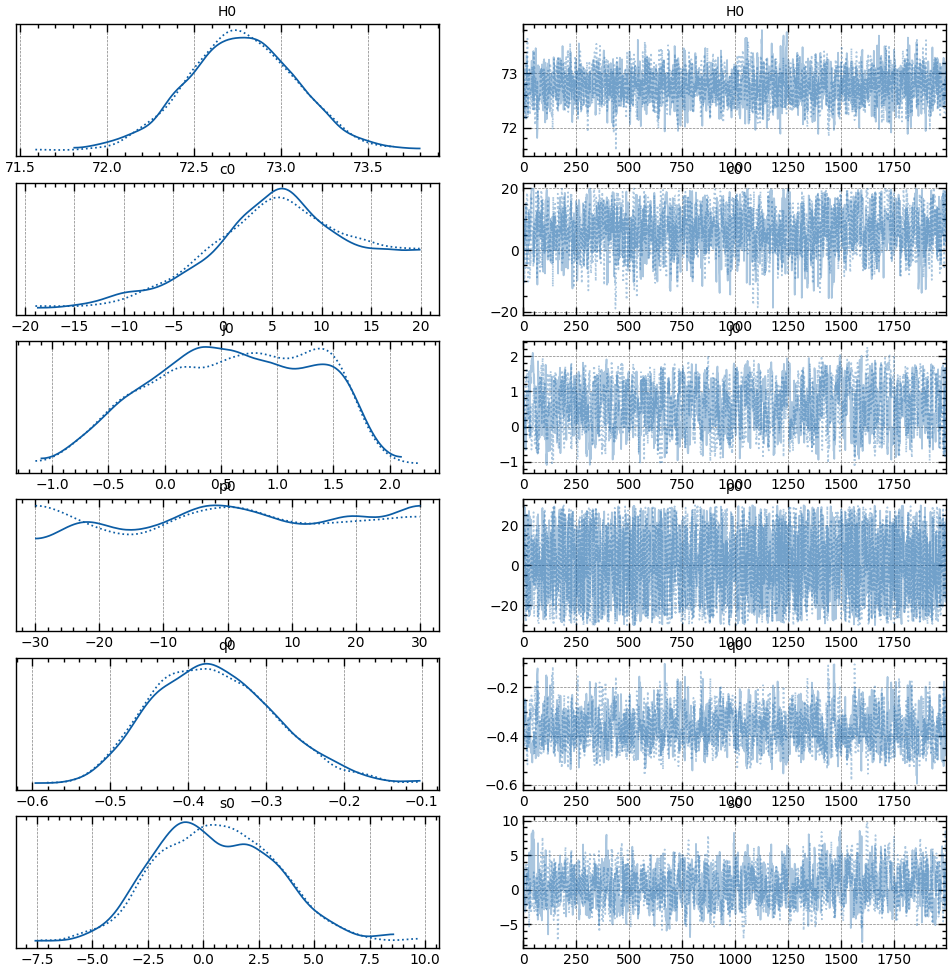

In [20]:
idata = az.from_numpyro(mcmc)
az.plot_trace(idata)

array([[<Axes: title={'center': 'H0'}>, <Axes: title={'center': 'c0'}>,
        <Axes: title={'center': 'j0'}>],
       [<Axes: title={'center': 'p0'}>, <Axes: title={'center': 'q0'}>,
        <Axes: title={'center': 's0'}>]], dtype=object)

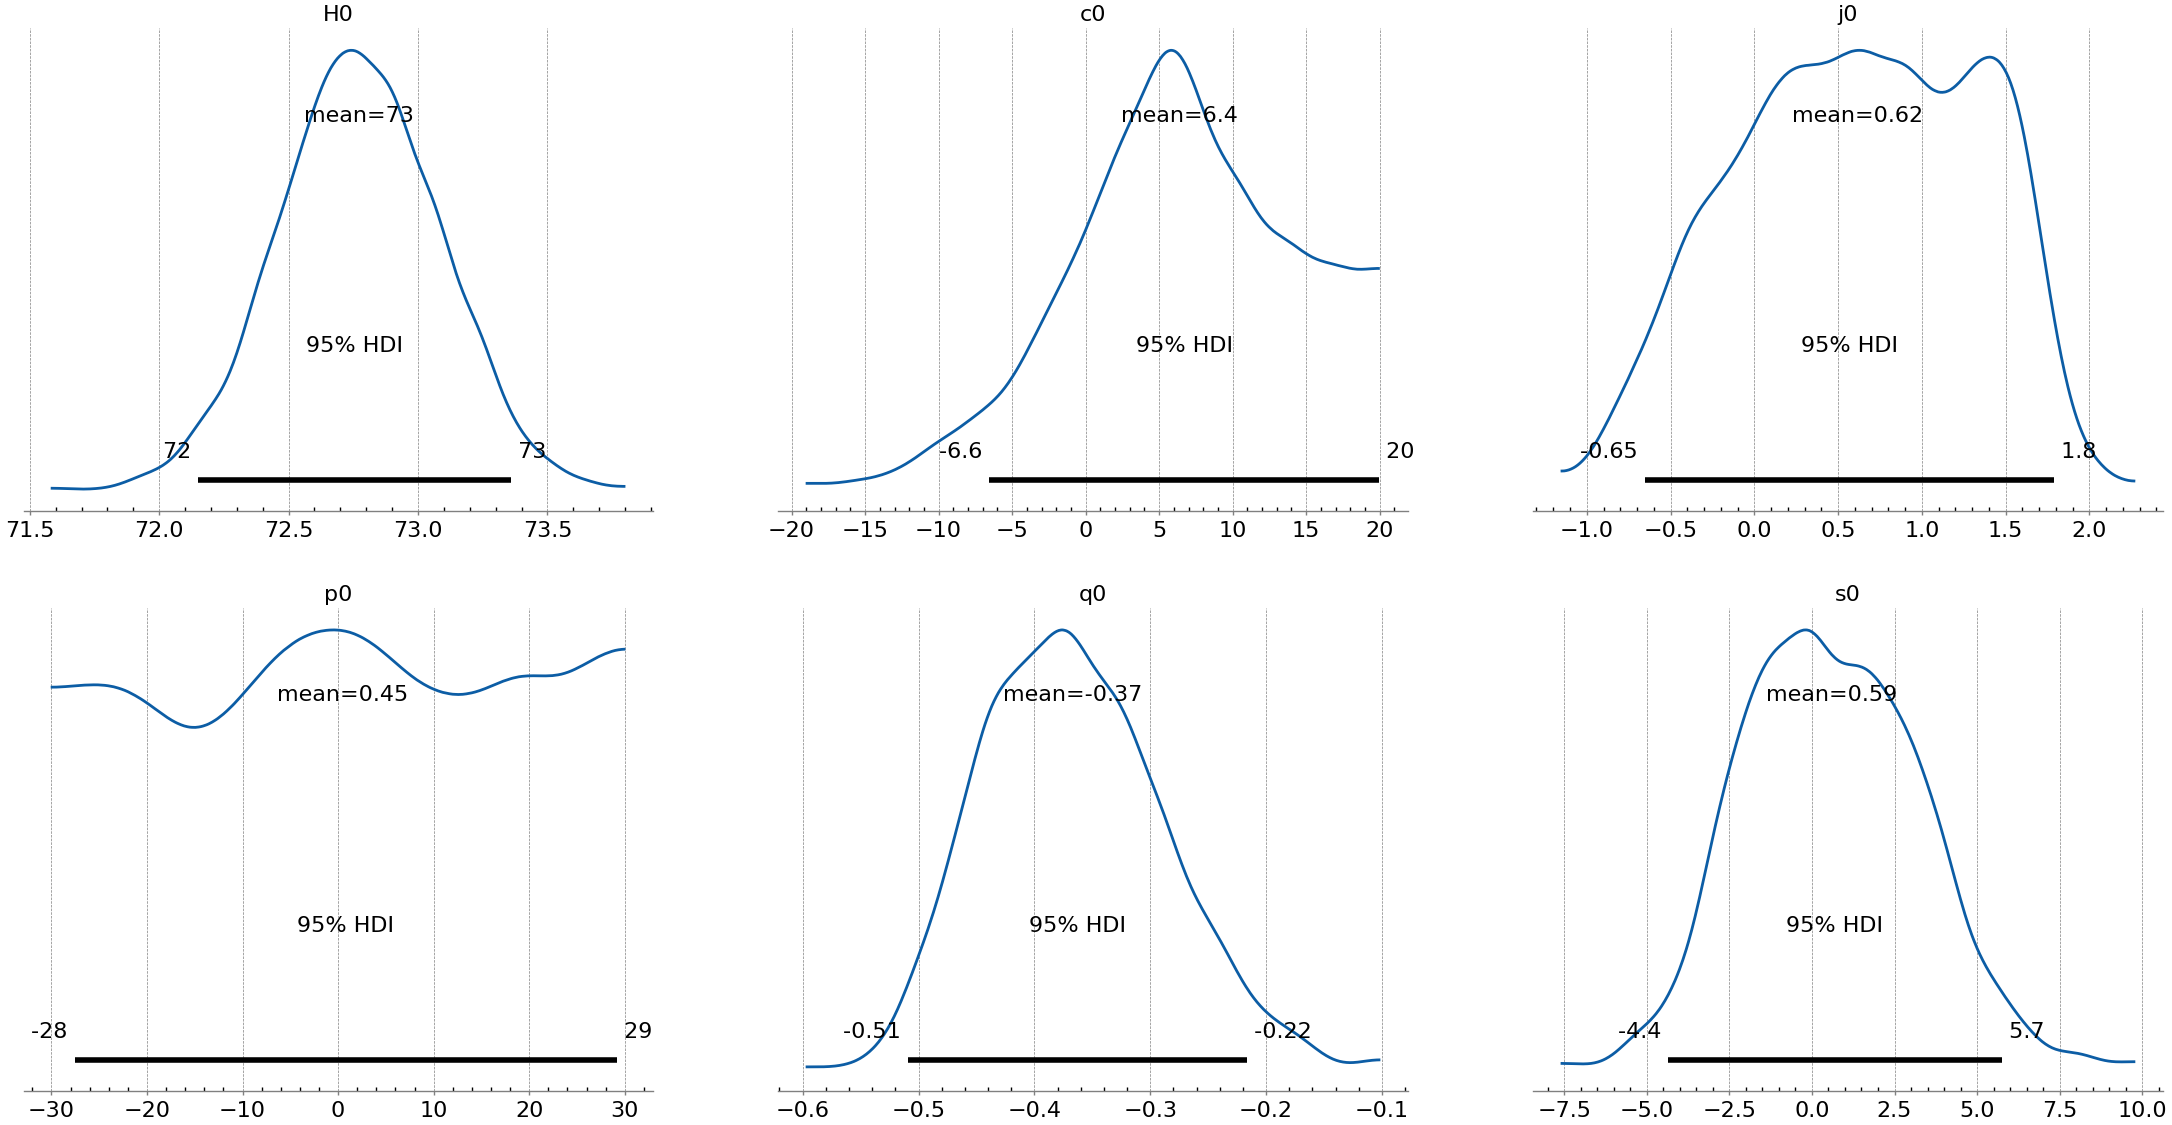

In [21]:
az.plot_posterior(idata, kind="kde", hdi_prob=0.95)

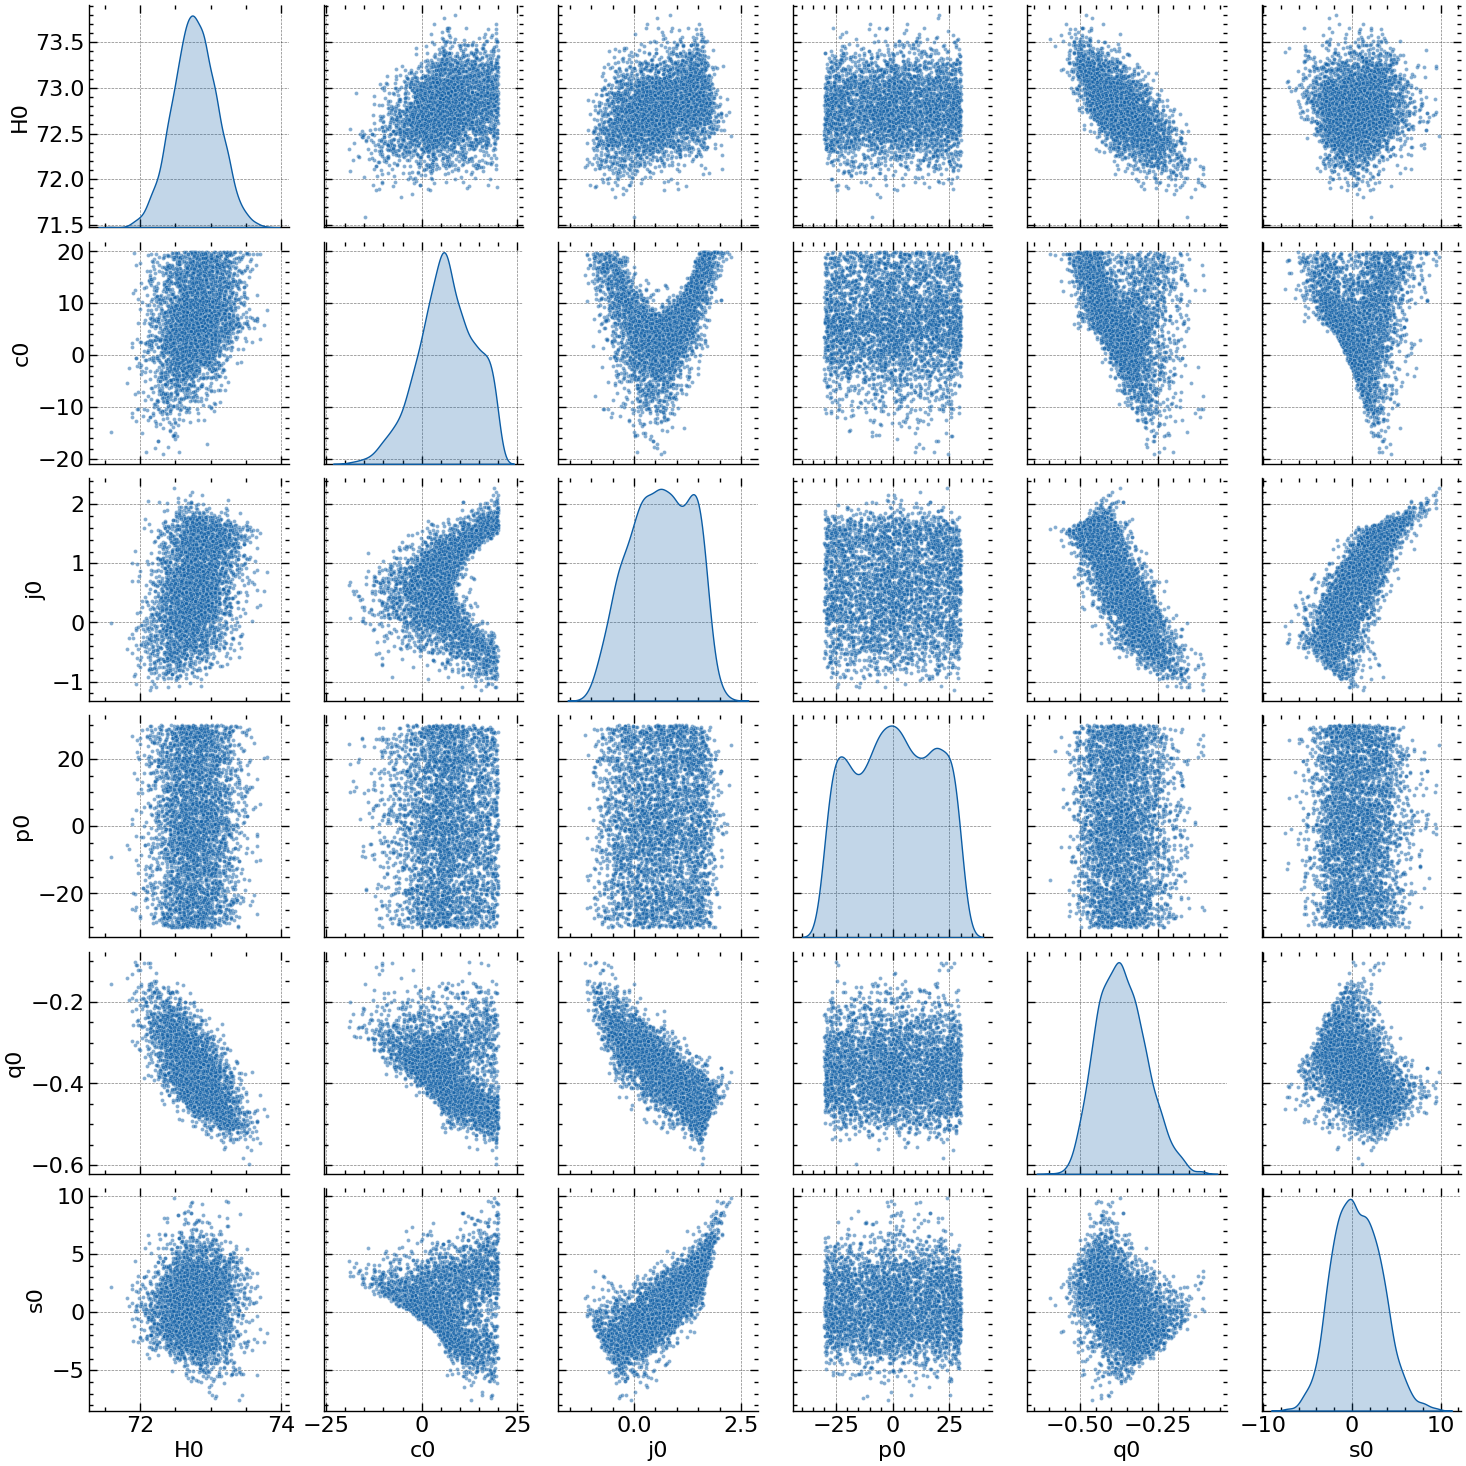

In [25]:
samples = mcmc.get_samples()
df = pd.DataFrame({k: np.array(v) for k, v in samples.items()})
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df,
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 8}
)

plt.show()

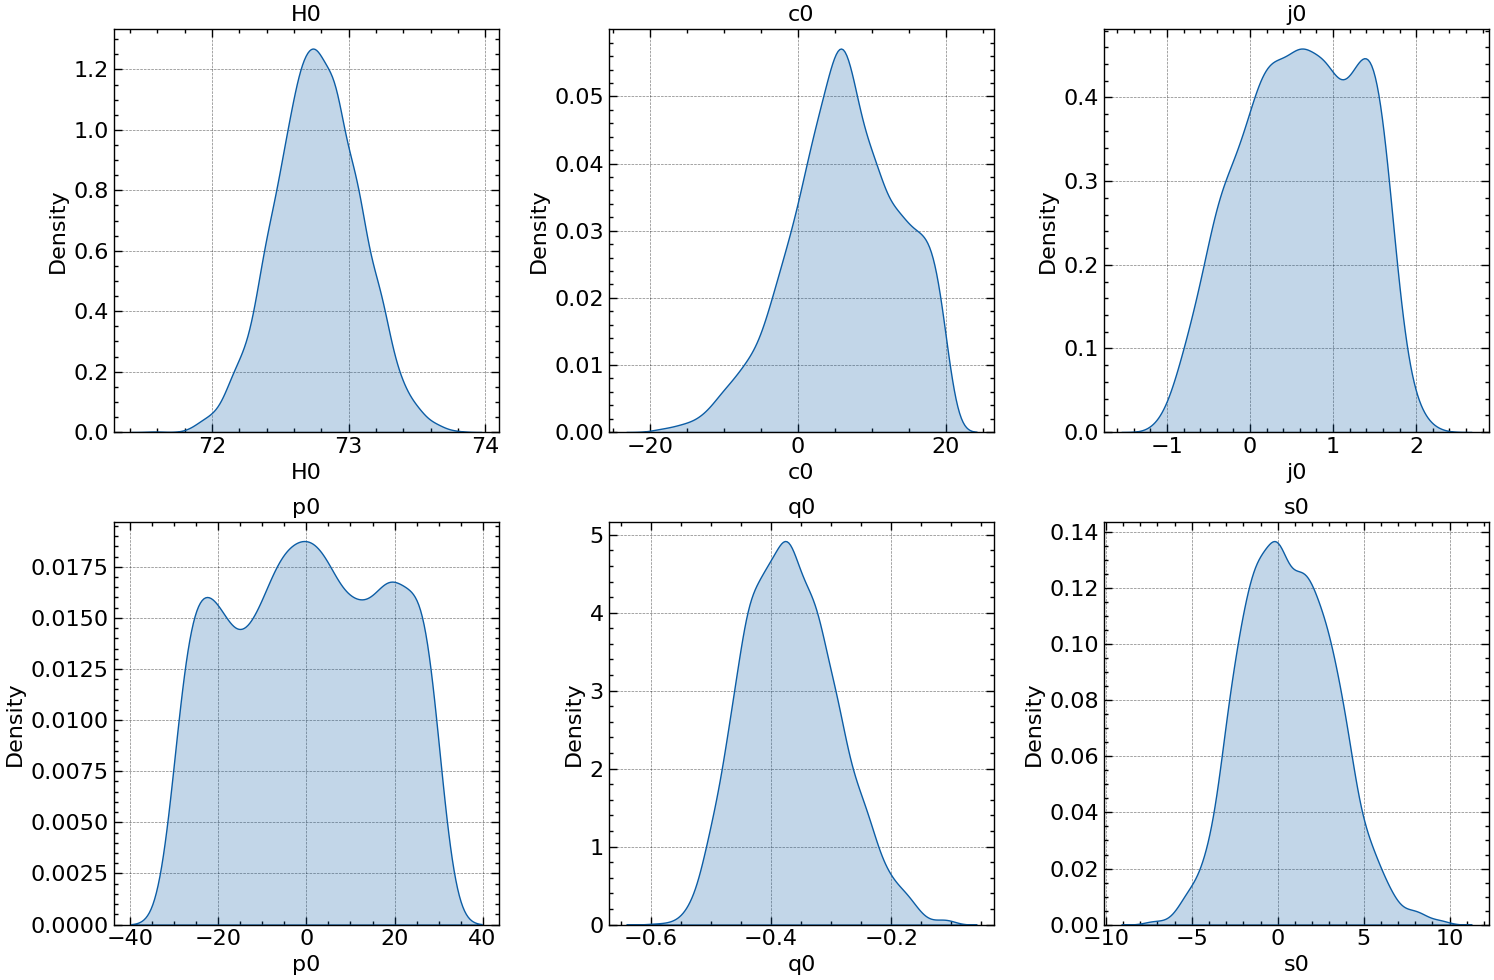

In [26]:
import math

params = df.columns
n = len(params)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(15, 10))

for i, p in enumerate(params, 1):
    plt.subplot(rows, cols, i)
    sns.kdeplot(df[p], fill=True)
    plt.title(p)

plt.tight_layout()
plt.show()

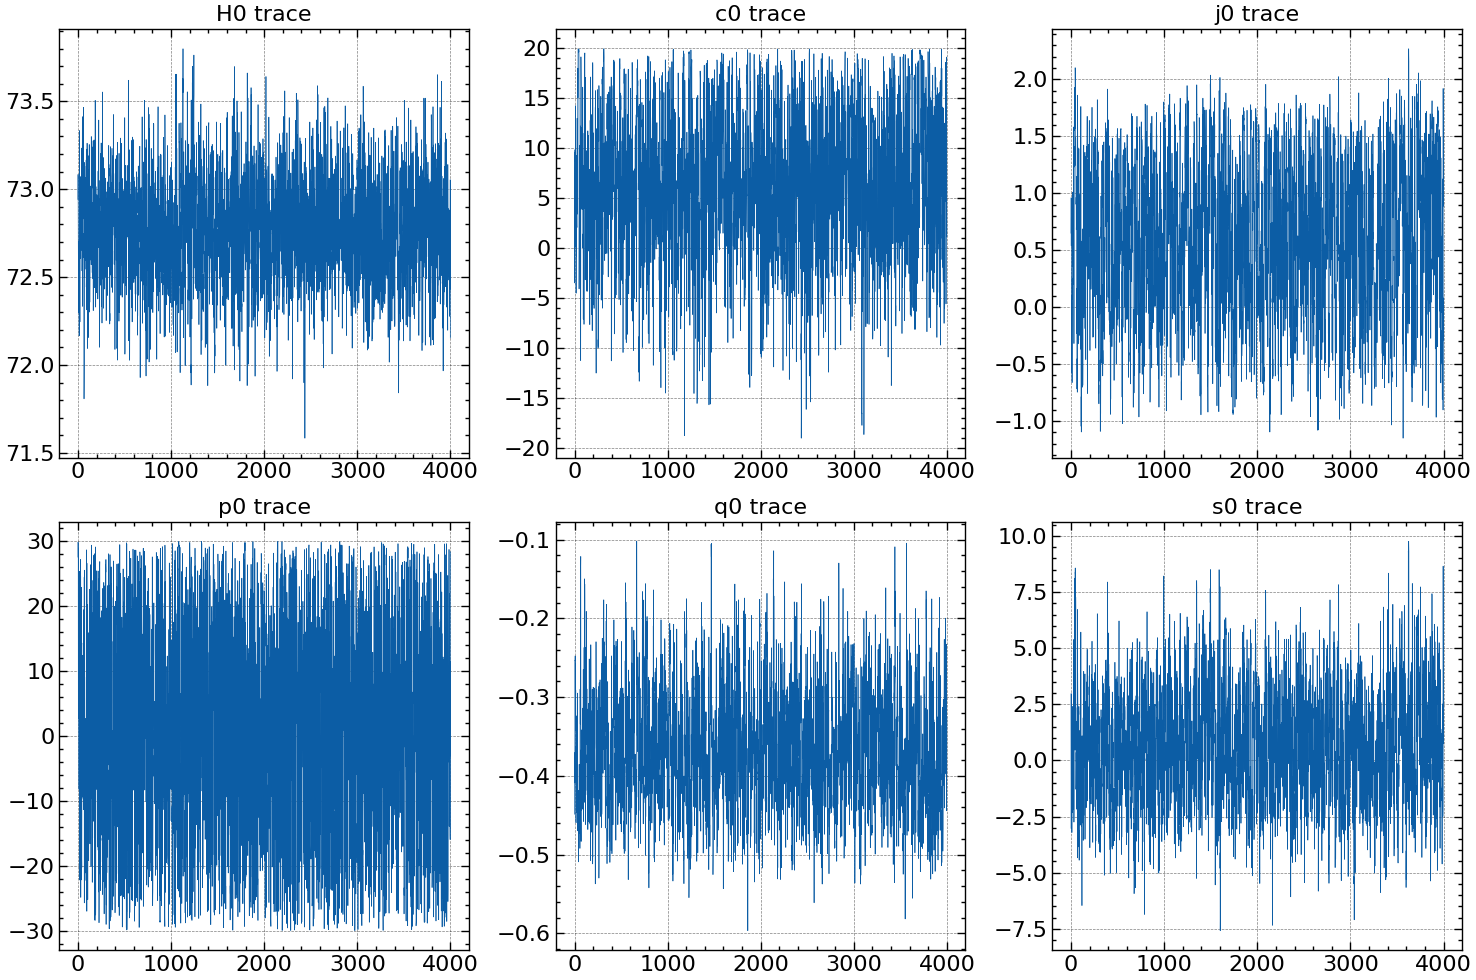

In [27]:
plt.figure(figsize=(15, 10))

for i, p in enumerate(params, 1):
    plt.subplot(rows, cols, i)
    plt.plot(df[p], linewidth=0.5)
    plt.title(p + " trace")

plt.tight_layout()
plt.show()


array([[<Axes: ylabel='H0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='q0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='j0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='s0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='c0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: xlabel='H0', ylabel='p0'>, <Axes: xlabel='q0'>,
        <Axes: xlabel='j0'>, <Axes: xlabel='s0'>, <Axes: xlabel='c0'>,
        <Axes: xlabel='p0'>]], dtype=object)

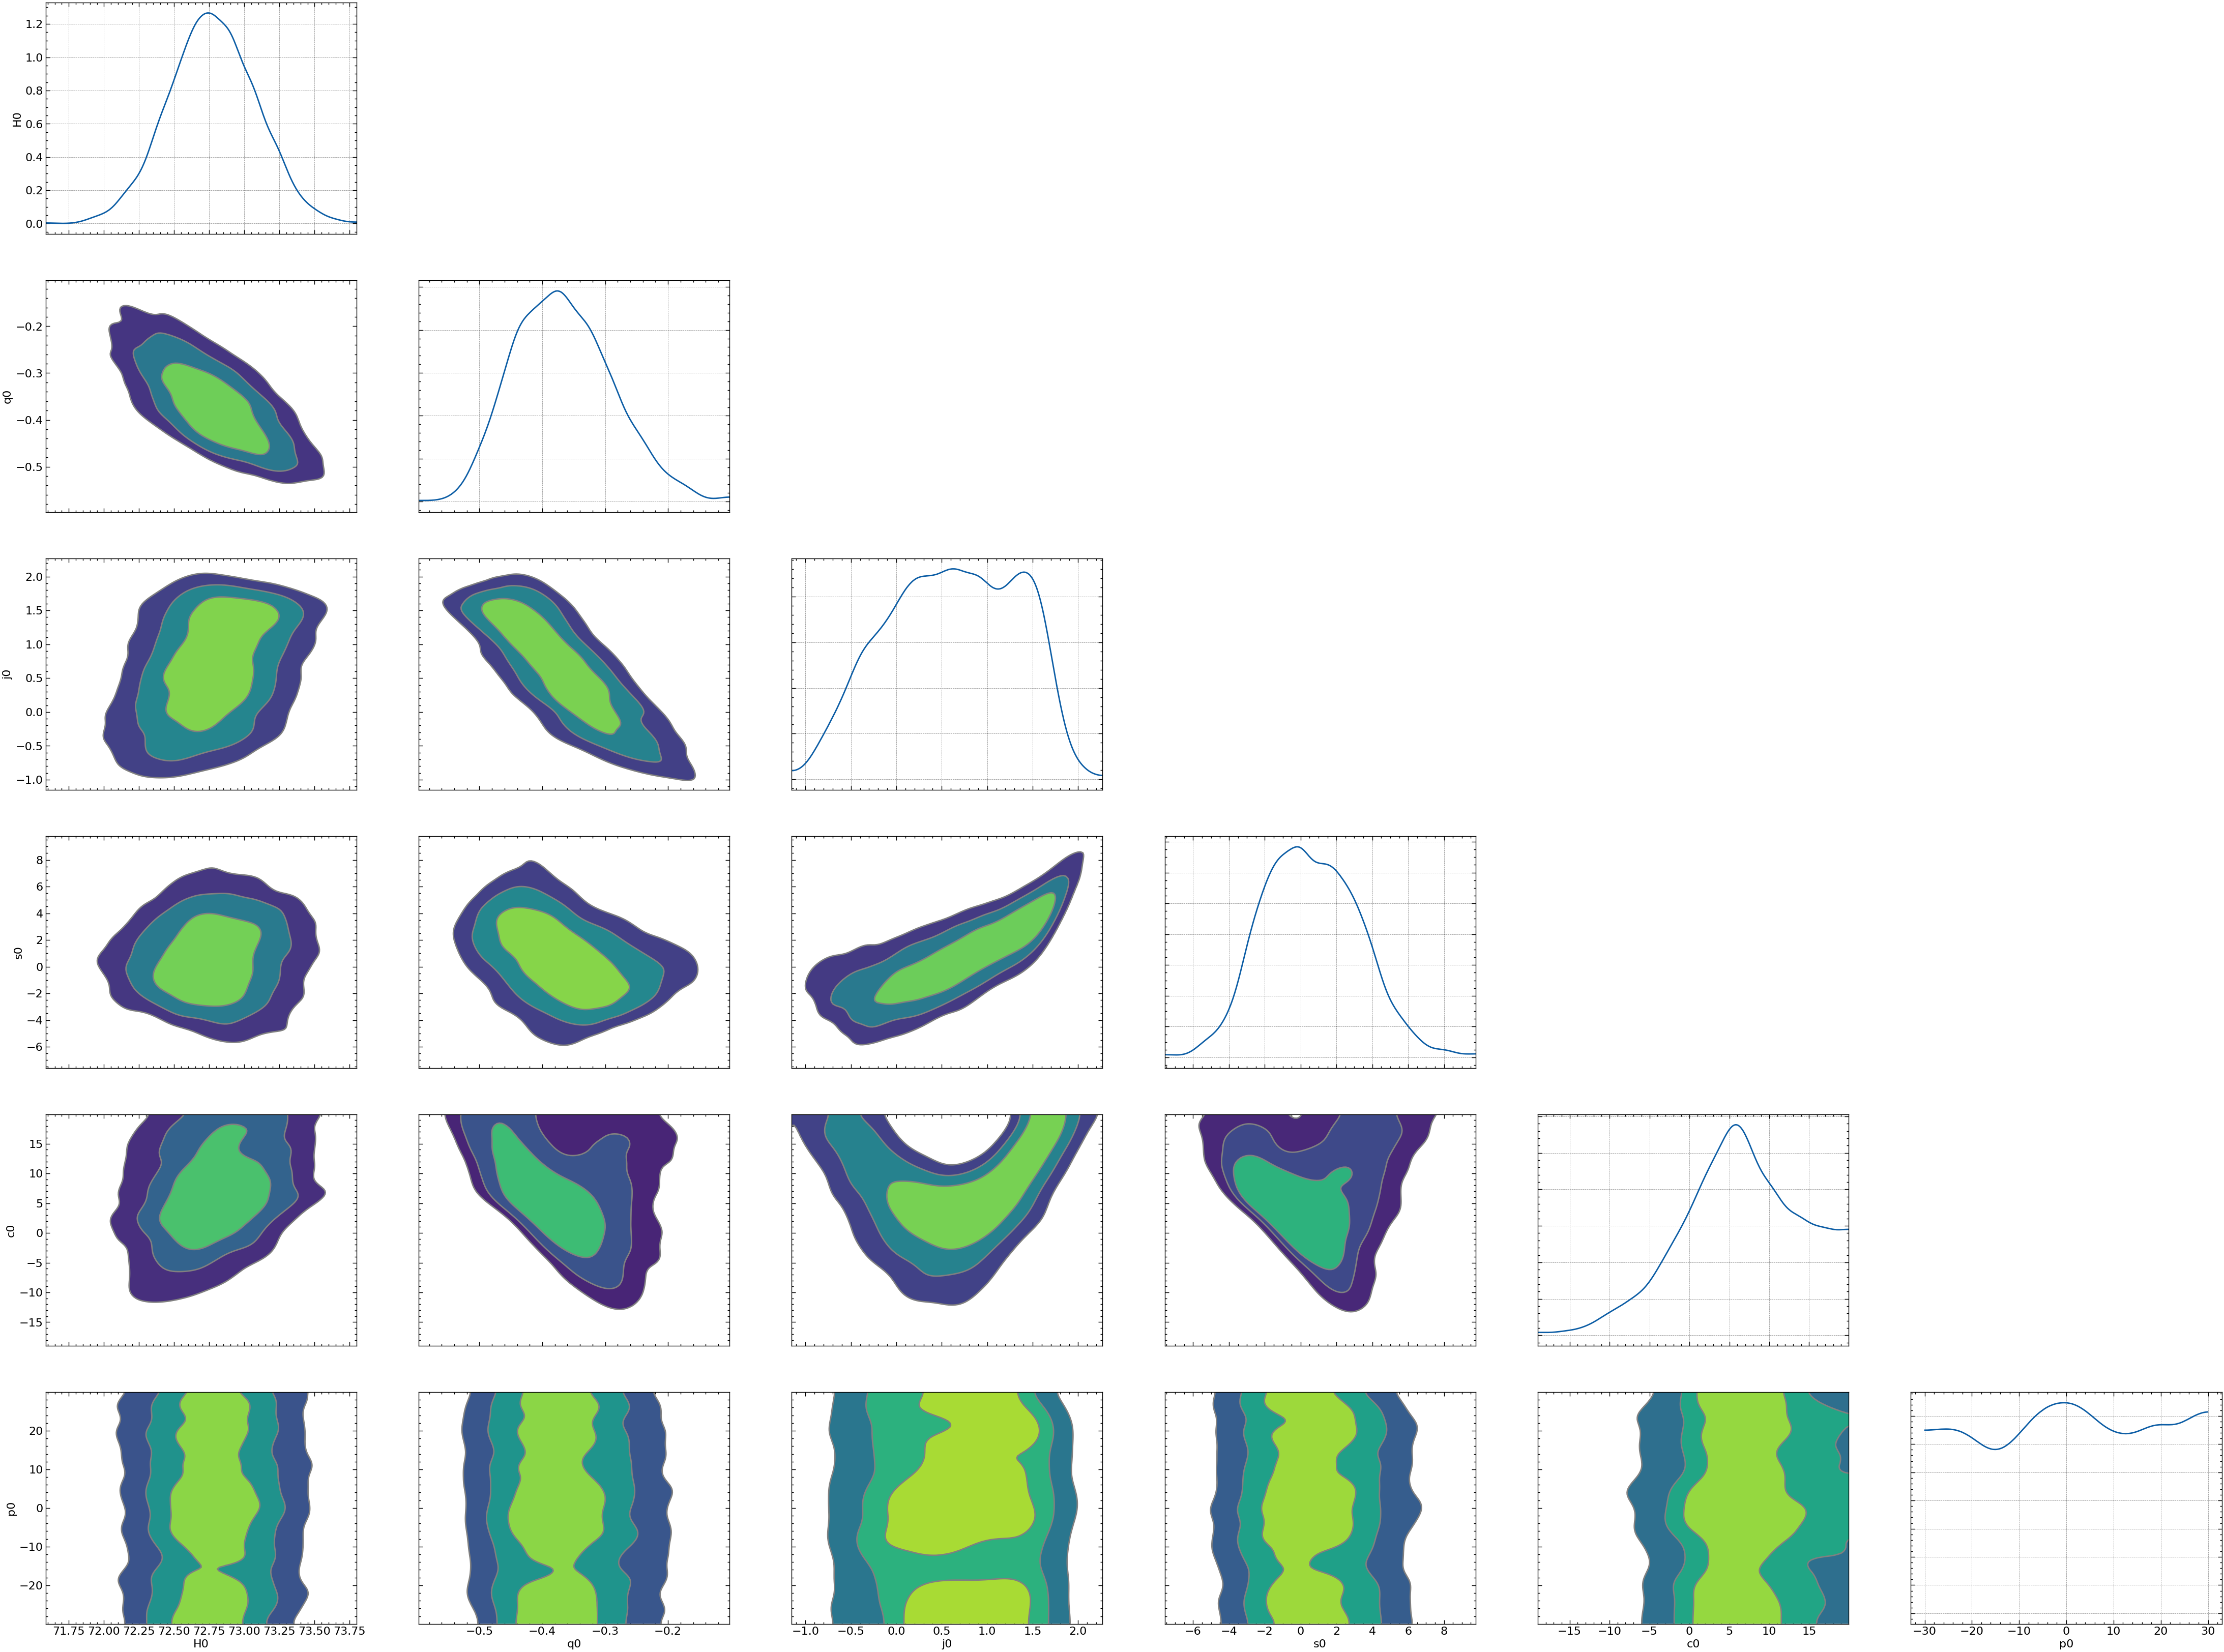

In [22]:
az.plot_pair(
    idata,
    var_names=["H0","q0","j0","s0","c0","p0"],
    kind="kde",
    marginals=True
)